## Synthetic Control

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt

collisions_ca = pd.read_csv(r"California_Collisions_Clean.csv")

In [2]:
!pip install sdid

In [3]:
from sdid import SyntheticDiffInDiff

## Fix Data before Modeling

In [ ]:
collisions_ca

In [14]:
#restructure data
monthly_did_data = (collisions_ca.groupby(['Agency', 'year_month'])
             .size()
             .reset_index(name='crashes'))

monthly_did_data['year_month'] = pd.to_datetime(monthly_did_data['year_month'])
monthly_did_data['year_month'] = monthly_did_data['year_month'].astype('period[M]')
monthly_did_data['year_month'] = monthly_did_data['year_month'].dt.to_timestamp()

monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

print(monthly_did_data.shape)
print(monthly_did_data.columns)

(1596, 3)
Index(['Agency', 'year_month', 'crashes'], dtype='object')


In [16]:
TREATMENT_DATE = pd.Timestamp('2014-04-01')  #Closest date after March 18th, 2014
TREATED_CITY   = 'San Francisco'

monthly_did_data['post'] = (monthly_did_data['year_month'] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)


###  Find Control Cities

In [17]:
for c in monthly_did_data['Agency'].unique():
  print(c)

Anaheim
Bakersfield
Fontana
Fresno
Garden Grove
Glendale
Irvine
Long Beach
Modesto
Oakland
Ontario
Pasadena
Pomona
Riverside
Sacramento
San Bernardino
San Francisco
Santa Ana
Stockton


### Convert Year Month Variable to a numeric counter

In [19]:
#Convert time to readable format
# Convert year_month to numeric (months since first period)
monthly_did_data['time_numeric'] = (
    (monthly_did_data['year_month'].dt.year - monthly_did_data['year_month'].dt.year.min()) * 12 +
    (monthly_did_data['year_month'].dt.month - monthly_did_data['year_month'].dt.month.min())
)

min_year = monthly_did_data['year_month'].dt.year.min()
min_month = monthly_did_data['year_month'].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

## Create Model

In [20]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

INFO:sdid.core:Data validated: 1 treated units, 18 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 102.6868
INFO:sdid.core:Unit weights estimated: 6 units with non-zero weights
INFO:sdid.core:Unit intercept: -572.8876
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 51.9476
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...
INFO:sdid.core:Treatment effect: 171.7879
INFO:sdid.core:SDID analysis complete!


In [21]:
print(type(result))
print(dir(result))
print(result)

<class 'numpy.float64'>
['T', '__abs__', '__add__', '__and__', '__array__', '__array_interface__', '__array_namespace__', '__array_priority__', '__array_struct__', '__array_wrap__', '__bool__', '__ceil__', '__class__', '__class_getitem__', '__copy__', '__deepcopy__', '__delattr__', '__dir__', '__divmod__', '__doc__', '__eq__', '__float__', '__floor__', '__floordiv__', '__format__', '__ge__', '__getattribute__', '__getformat__', '__getitem__', '__getnewargs__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__int__', '__invert__', '__le__', '__lshift__', '__lt__', '__mod__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rlshift__', '__rmod__', '__rmul__', '__ror__', '__round__', '__rpow__', '__rrshift__', '__rshift__', '__rsub__', '__rtruediv__', '__rxor__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__sub__', '__subcla

INFO:sdid.core:Creating synthetic control plot...
INFO:sdid.core:Creating raw trends plot...


'==================================================\nSynthetic Difference-in-Differences Results\n==================================================\nTreatment Effect (ATT): 171.7879\nControl units used:    6\nTime periods used:     0\n=================================================='

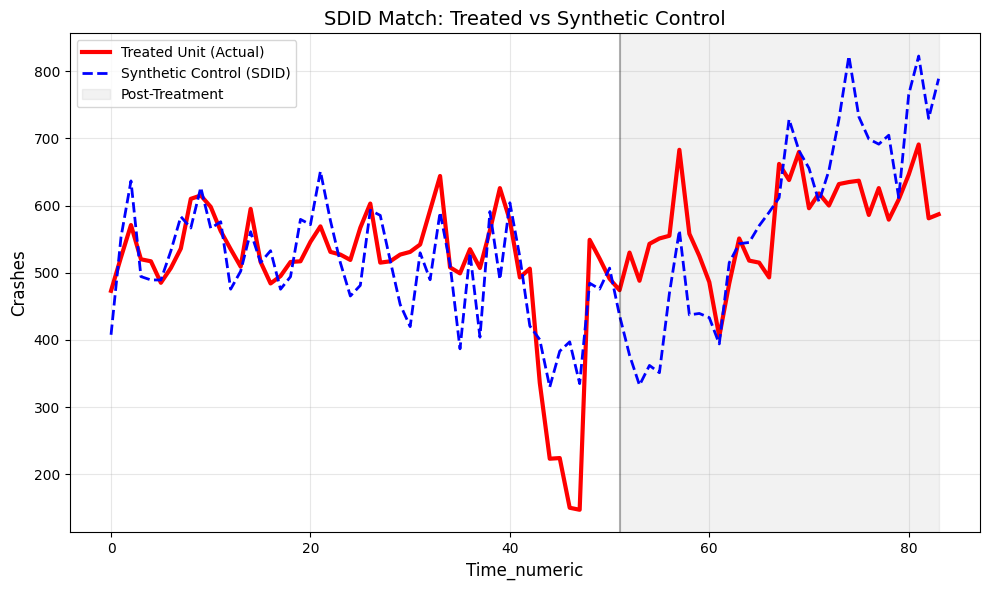

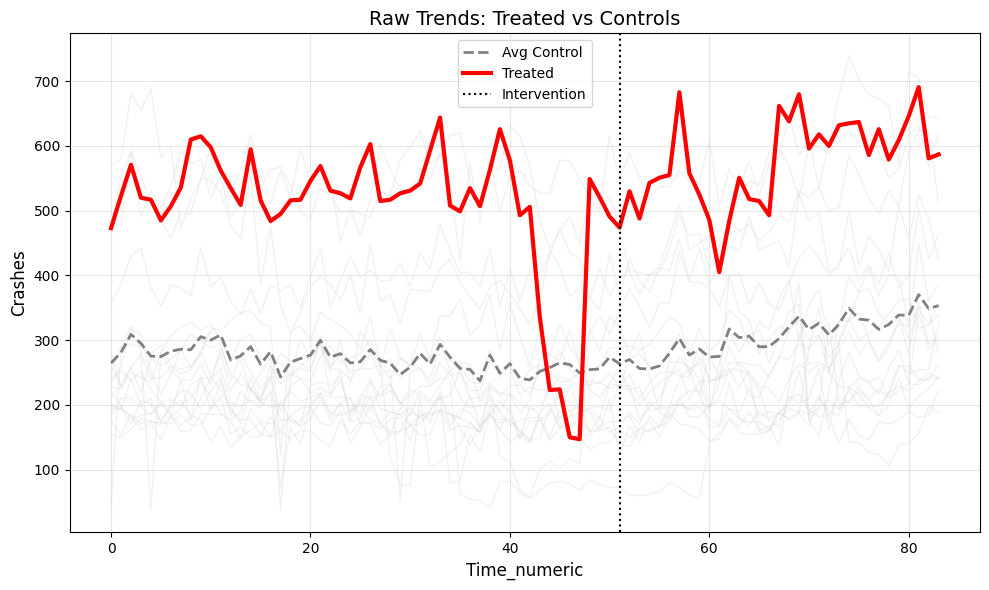

In [22]:
# 1. Synthetic control vs actual SF trends
model.plot_synthetic_control()

# 2. Raw trends for all cities
model.plot_raw_trends()

# Also print the full summary
model.summary()

In [23]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

INFO:sdid.core:Estimating standard error with 200 bootstrap samples...
INFO:sdid.core:Standard error: 78.1205


Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 171.7879
Standard Error:        78.1205
95% Confidence Interval: [18.6746, 324.9012]
t-statistic:           2.1990
p-value:               0.0279
Control units used:    6
Time periods used:     0


In [24]:
model.get_weights_summary()

{'unit_weights':                 weight  rank
 Agency                      
 Long Beach    1.130991   1.0
 Pasadena      0.841860   2.0
 Garden Grove  0.521374   3.0
 Riverside     0.508788   4.0
 Fresno        0.289043   5.0
 Stockton      0.074993   6.0,
 'time_weights': Empty DataFrame
 Columns: [weight, rank]
 Index: []}